In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

In [2]:
def read_decode_depth(depthpath):
    depth_rgba = cv2.imread(depthpath, cv2.IMREAD_UNCHANGED)
    depth = depth_rgba.view("<f4")
    return np.squeeze(depth, axis=-1)

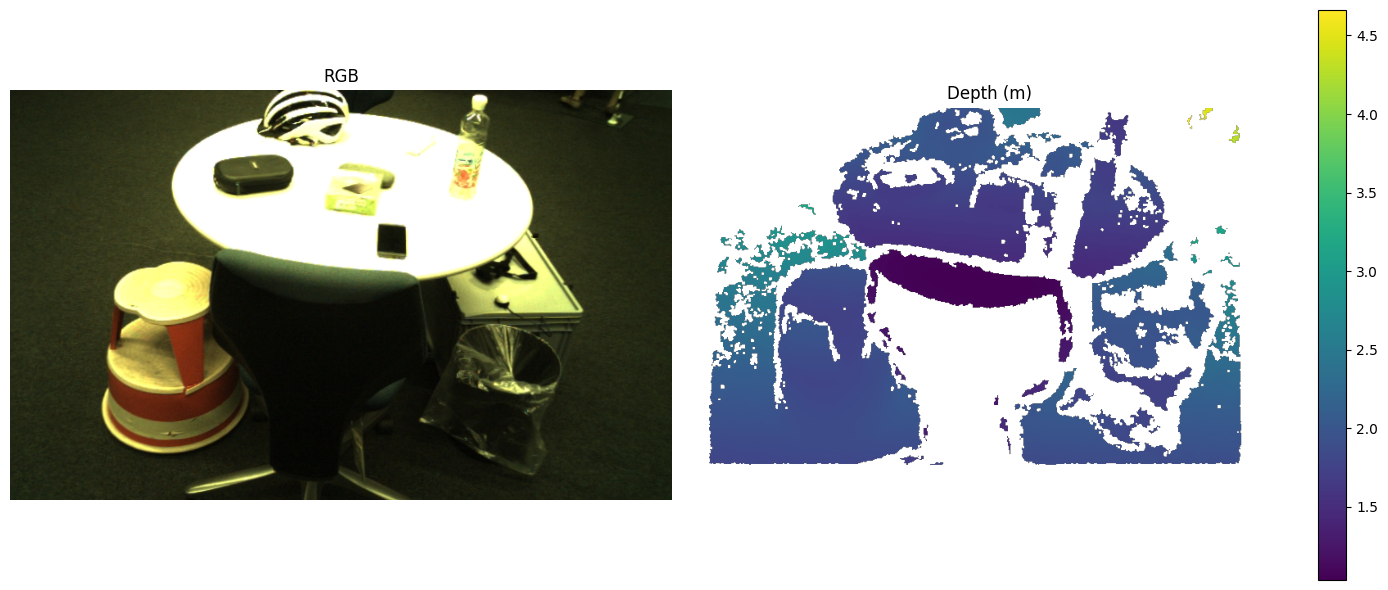

In [17]:
data_root = Path("/Volumes/T9/datasets")
# /Volumes/T9/datasets/tum-rgbd/rgbd_dataset_freiburg3_structure_notexture_far/depth
depth_path = data_root / "eth3d" / "training" / "table_3" / "depth" / "3018.956984.png"
rgb_path = data_root / "eth3d" / "training" / "table_3" / "rgb" / "3018.956984.png"
# depth_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "depth_lcam_front" / "000000_lcam_front_depth.png"
# rgb_path = data_root / "tartanair-v2" / "ArchVizTinyHouseDay" / "Data_easy" / "ArchVizTinyHouseDay" / "Data_easy" / "P000" / "image_lcam_front" / "000000_lcam_front.png"

depth_raw = np.array(Image.open(depth_path))
# depth_raw = read_decode_depth(depth_path)
img_raw = np.array(Image.open(rgb_path))

depth_m = depth_raw.astype(np.float32) / 5000.0

# depth_m = depth_raw.copy()
# depth_m[depth_m > 30.0] = np.nan  # threshold well above any indoor scene depth, well below sky-coded values

depth_m[depth_raw == 0.0] = np.nan


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(img_raw)
axes[0].set_title("RGB")
axes[0].axis("off")

im = axes[1].imshow(depth_m, cmap="viridis")
axes[1].set_title("Depth (m)")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

95th percentile sigma_d: 29.81 cm


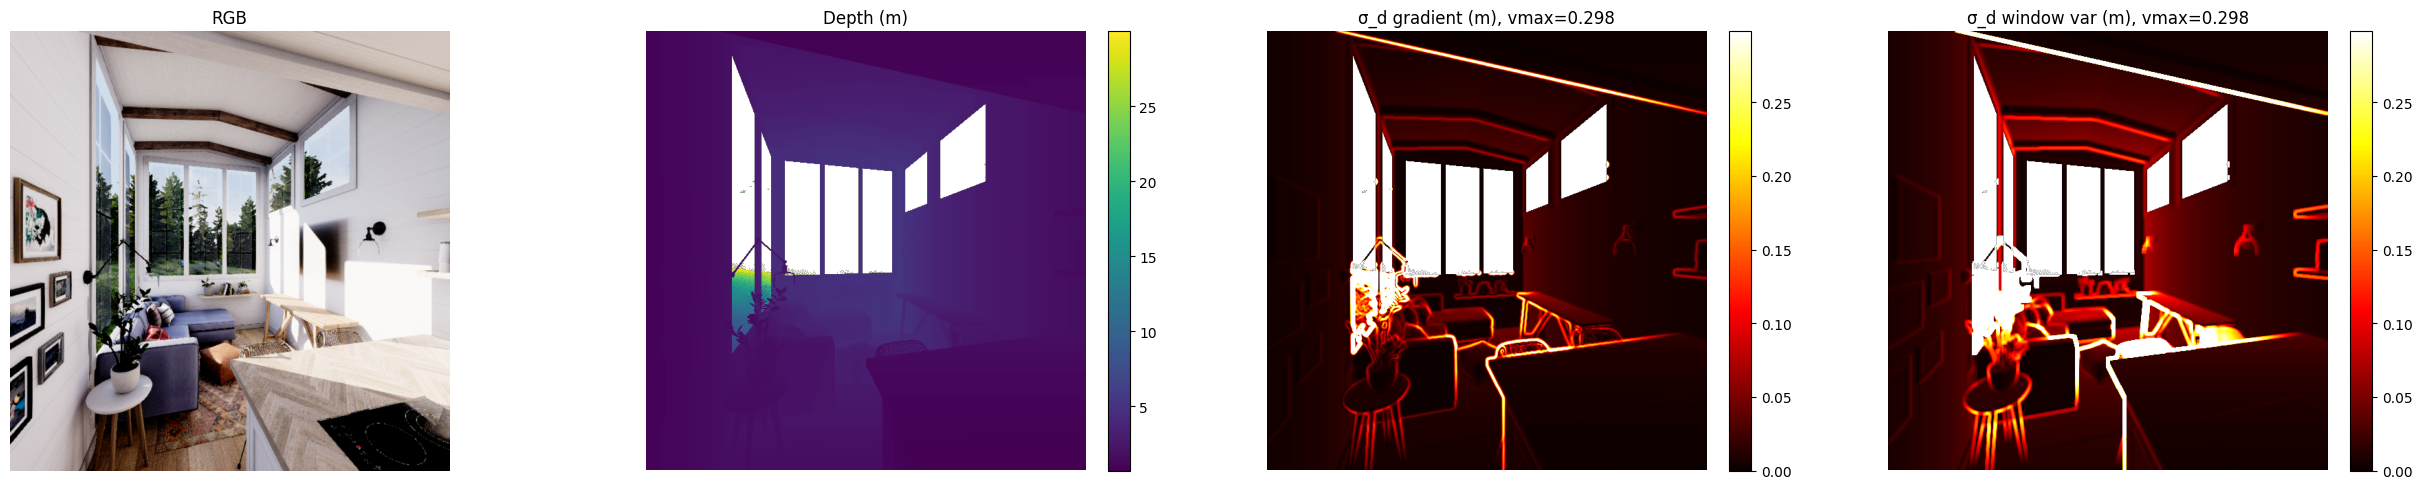

In [5]:
from scipy.ndimage import gaussian_filter, uniform_filter

def depth_uncertainty_source1(depth, sigma_smooth=1.5, sigma_pixel=1.0):
    """
    Gradient term: sigma^2_d = grad^T Sigma_2D grad, isotropic 2D version.
    
    For isotropic 2D noise (sigma_pixel), this reduces to:
        sigma^2_d = (grad_u^2 + grad_v^2) * sigma_pixel^2
    
    Captures along-surface depth change due to 2D detection noise.
    Smooths depth before computing gradient to suppress sensor noise
    and dropout-edge artifacts.
    
    Parameters
    ----------
    depth : (H, W) array, depth in meters, NaN for invalid
    sigma_smooth : float, Gaussian smoothing sigma (pixels) for gradient
    sigma_pixel : float, assumed 2D detection noise std (pixels)
    
    Returns
    -------
    var_d : (H, W) array, depth variance contribution from gradient term (m^2)
    """
    valid = ~np.isnan(depth)
    weight = valid.astype(np.float32)
    
    # NaN-aware Gaussian smoothing: smooth depth*weight and weight separately,
    # then divide. This handles invalid pixels properly.
    depth_filled = np.where(valid, depth, 0.0)
    smoothed_num = gaussian_filter(depth_filled * weight, sigma=sigma_smooth)
    smoothed_den = gaussian_filter(weight, sigma=sigma_smooth)
    
    # Avoid divide-by-zero where the local neighborhood is all invalid
    smoothed = np.where(smoothed_den > 0.1, smoothed_num / np.maximum(smoothed_den, 1e-6), np.nan)
    
    # Centered finite differences for gradient
    grad_v, grad_u = np.gradient(smoothed)
    
    grad_mag_sq = grad_u**2 + grad_v**2
    var_d = grad_mag_sq * (sigma_pixel ** 2)
    
    # Mask result where original pixel was invalid
    var_d = np.where(valid, var_d, np.nan)
    return var_d


def depth_uncertainty_source2(depth, window_size=5):
    """
    Window variance term: Var(d) computed in a local window around each pixel.
    
    Captures depth discontinuities ('hopping' between near and far surfaces).
    NaN-aware: only uses valid pixels in the variance computation.
    
    Parameters
    ----------
    depth : (H, W) array, depth in meters, NaN for invalid
    window_size : int, side length of square window (pixels)
    
    Returns
    -------
    var_d : (H, W) array, depth variance from local window (m^2)
    """
    valid = ~np.isnan(depth)
    weight = valid.astype(np.float32)
    depth_filled = np.where(valid, depth, 0.0)
    
    # Weighted mean and mean-of-squares using uniform filter (box filter)
    # E[d] = sum(d * w) / sum(w)
    # Var[d] = E[d^2] - E[d]^2
    sum_w = uniform_filter(weight, size=window_size) * (window_size ** 2)
    sum_dw = uniform_filter(depth_filled * weight, size=window_size) * (window_size ** 2)
    sum_d2w = uniform_filter(depth_filled**2 * weight, size=window_size) * (window_size ** 2)
    
    # Need at least a few valid samples to compute variance meaningfully
    enough_samples = sum_w >= 4
    
    mean = np.where(enough_samples, sum_dw / np.maximum(sum_w, 1.0), np.nan)
    mean_sq = np.where(enough_samples, sum_d2w / np.maximum(sum_w, 1.0), np.nan)
    var = mean_sq - mean**2
    var = np.maximum(var, 0)  # numerical floor
    var = np.where(valid & enough_samples, var, np.nan)
    return var


def nan_density(depth, window_size=5):
    """
    Fraction of NaN pixels in a local window. Useful for masking
    regions where the formulation is unreliable due to dropout.
    """
    valid = ~np.isnan(depth)
    fill_fraction = uniform_filter(valid.astype(np.float32), size=window_size)
    return 1.0 - fill_fraction

def depth_uncertainty_nan_proximity(depth, window_size=7, sigma_default=0.10):
    """
    NaN proximity term for sensor data with systematic dropout at edges.
    Uses NaN fraction as a discontinuity proxy.
    """
    nan_frac = nan_density(depth, window_size=window_size)
    var_d = (nan_frac ** 2) * (sigma_default ** 2)
    return var_d
    
# Compute the maps
var_grad = depth_uncertainty_source1(depth_m, sigma_smooth=1.5, sigma_pixel=1.0)
var_window = depth_uncertainty_source2(depth_m, window_size=7)
var_nan_prox = depth_uncertainty_nan_proximity(depth_m, window_size=7)
var_total = np.where(
    np.isnan(var_grad) | np.isnan(var_window),
    np.nan,
    var_grad + var_window
)
nan_frac = nan_density(depth_m, window_size=5)

sigma_grad = np.sqrt(var_grad)
sigma_window = np.sqrt(var_window)
sigma_total = np.sqrt(var_total)
sigma_prox = np.sqrt(var_nan_prox)

# Pick a vmax for the uncertainty heatmaps based on the data
# 95th percentile is a reasonable cap; tune if needed
vmax = np.nanpercentile(sigma_total, 95)
print(f"95th percentile sigma_d: {vmax*100:.2f} cm")

# Five-panel visualization
fig, axes = plt.subplots(1, 4, figsize=(25, 5))

axes[0].imshow(img_raw)
axes[0].set_title("RGB")
axes[0].axis("off")

im1 = axes[1].imshow(depth_m, cmap="viridis")
axes[1].set_title("Depth (m)")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(sigma_grad, cmap="hot", vmin=0, vmax=vmax)
axes[2].set_title(f"σ_d gradient (m), vmax={vmax:.3f}")
axes[2].axis("off")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(sigma_window, cmap="hot", vmin=0, vmax=vmax)
axes[3].set_title(f"σ_d window var (m), vmax={vmax:.3f}")
axes[3].axis("off")
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# im4 = axes[4].imshow(sigma_prox, cmap="gray_r", vmin=0, vmax=vmax)
# axes[4].set_title("var nan prox")
# axes[4].axis("off")
# plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()